# Stage B - Fine-tuning ResNet-18 Classifier
Train an ImageNet-pretrained ResNet-18 expert on 100 classes with freeze/unfreeze scheduling.

In [1]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import yaml
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Ensure imports from project root work regardless of notebook working directory.
project_root = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.dataset import get_dataloaders
from src.classifier import get_classifier
from src.train_classifier import train_classifier

In [2]:
config_path = project_root / 'configs' / 'config.yaml'
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Resolve all important paths from the project root so notebook cwd does not matter.
data_root = (project_root / config['dataset']['root']).resolve()
models_dir = (project_root / 'models').resolve()
classifier_save_path = models_dir / 'resnet_classifier.pth'
classifier_ckpt_dir = models_dir / 'checkpoints' / 'classifier'

device = config['training']['device'] if torch.cuda.is_available() else 'cpu'
model = get_classifier(
    num_classes=config['dataset']['num_classes'],
    pretrained=config['classifier']['pretrained']
).to(device)
print(f'Using data root: {data_root}')
print(f'Checkpoint dir: {classifier_ckpt_dir}')
model

Using data root: C:\Users\Akash\Desktop\SelfHealingNN\data\raw
Checkpoint dir: C:\Users\Akash\Desktop\SelfHealingNN\models\checkpoints\classifier


SelfHealingClassifier(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=

In [3]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,}')
print(f'Total params: {total:,}')

Trainable params: 11,227,812
Total params: 11,227,812


In [4]:
train_loader, val_loader, test_loader = get_dataloaders(
    root=str(data_root),
    image_size=config['dataset']['image_size'],
    batch_size=config['classifier']['batch_size'],
    train_split=config['dataset']['train_split'],
    num_workers=config['training']['num_workers'],
    noisy=False
)

# Single-call training with freeze->unfreeze schedule is safer for checkpoint resume.
history = train_classifier(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=config['classifier']['epochs'],
    learning_rate=config['classifier']['learning_rate'],
    freeze_backbone_epochs=5,
    save_path=str(classifier_save_path),
    patience=config['training']['early_stopping_patience'],
    checkpoint_dir=str(classifier_ckpt_dir),
    checkpoint_interval=config['training']['checkpoint_interval'],
    auto_resume=config['training']['auto_resume'],
    use_amp=config['training']['amp'],
    grad_clip_norm=config['training']['grad_clip_norm'],
    early_stop_metric=str(config['training'].get('classifier_early_stop_metric', 'val_top1')),
)

print('Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.')

Epoch 001 | loss=0.2151/0.1498 | top1=0.9557/0.9665 | top5=0.9953/1.0000 | conf=0.9506/0.9634 | lr=9.97e-05


Epoch 002 | loss=0.1625/0.1501 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9692/0.9748 | lr=9.89e-05


Epoch 003 | loss=0.1615/0.1491 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9692/0.9733 | lr=9.76e-05


Epoch 004 | loss=0.1607/0.1476 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9692/0.9668 | lr=9.57e-05


Epoch 005 | loss=0.1601/0.1516 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9690/0.9796 | lr=9.33e-05


...

Epoch 007 | loss=0.1625/0.1516 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9645/0.9668 | lr=9.84e-05


Epoch 008 | loss=0.1623/0.1492 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9646/0.9587 | lr=9.65e-05


Epoch 009 | loss=0.1620/0.1506 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9640/0.9601 | lr=9.38e-05


Epoch 010 | loss=0.1615/0.1472 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9639/0.9575 | lr=9.05e-05


Epoch 011 | loss=0.1614/0.1471 | top1=0.9625/0.9665 | top5=1.0000/1.0000 | conf=0.9637/0.9645 | lr=8.64e-05
Early stopping triggered at epoch 11.
Training call complete. If interrupted, rerun this cell to resume from latest checkpoint.


In [5]:
# Resume note: this notebook now uses a single training call in Cell 5.
# If you stop training manually, just rerun Cell 5 and it will auto-resume from
# models/checkpoints/classifier/latest.pt.
print('Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.')

Resume workflow enabled: rerun Cell 5 to continue training from latest checkpoint.


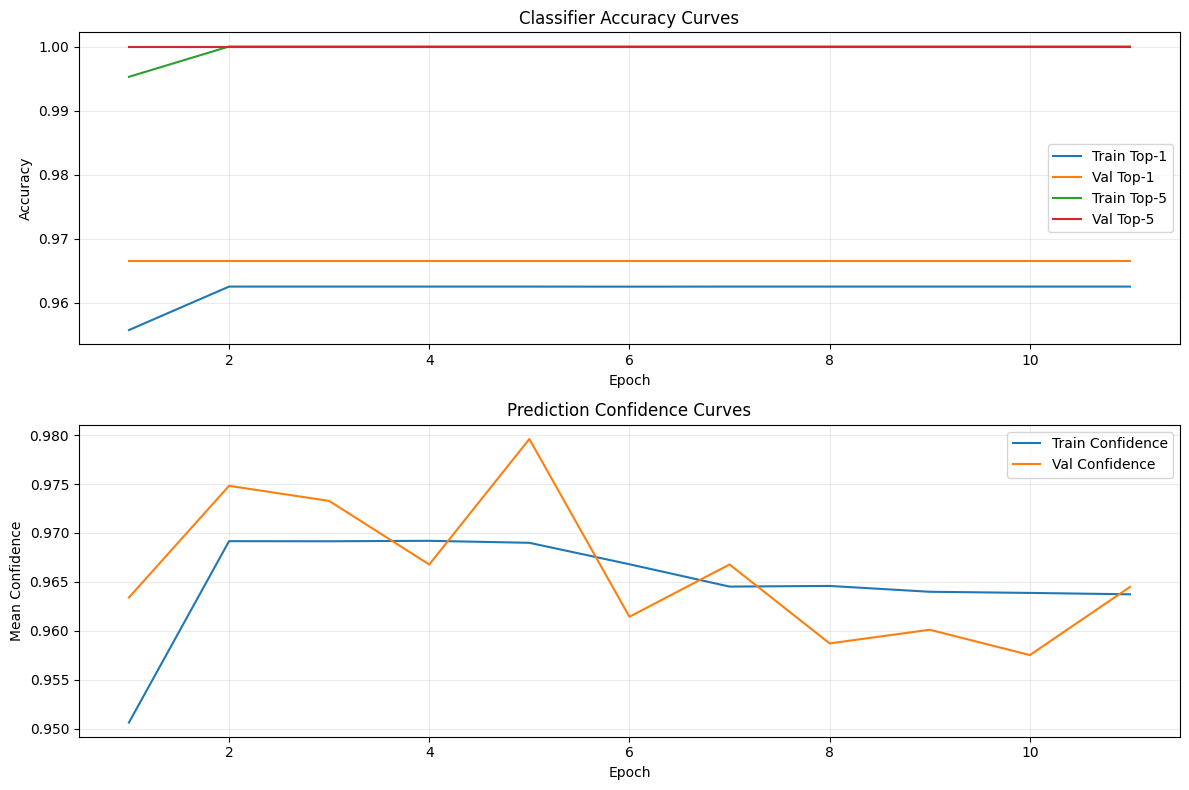

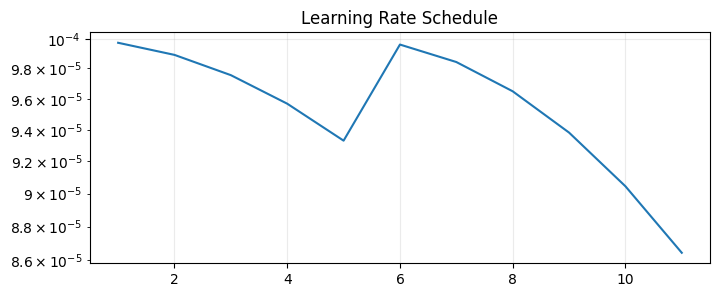

In [6]:
epochs = range(1, len(history['train_top1']) + 1)
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.plot(epochs, history['train_top1'], label='Train Top-1')
plt.plot(epochs, history['val_top1'], label='Val Top-1')
plt.plot(epochs, history['train_top5'], label='Train Top-5')
plt.plot(epochs, history['val_top5'], label='Val Top-5')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracy Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.subplot(2, 1, 2)
plt.plot(epochs, history.get('train_confidence', []), label='Train Confidence')
plt.plot(epochs, history.get('val_confidence', []), label='Val Confidence')
plt.xlabel('Epoch')
plt.ylabel('Mean Confidence')
plt.title('Prediction Confidence Curves')
plt.legend()
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

if history.get('lr'):
    plt.figure(figsize=(8, 3))
    plt.plot(epochs, history['lr'])
    plt.title('Learning Rate Schedule')
    plt.yscale('log')
    plt.grid(alpha=0.25)
    plt.show()

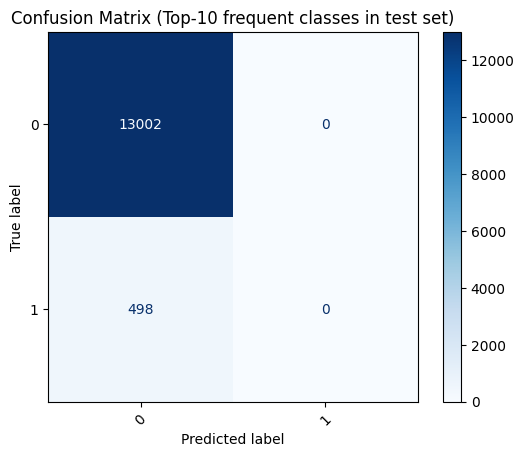

In [7]:
from collections import Counter

model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        preds = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_targets.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

class_counts = Counter(all_targets.tolist())
sample_classes = [cls for cls, _ in class_counts.most_common(10)]
cm = confusion_matrix(all_targets, all_preds, labels=sample_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sample_classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix (Top-10 frequent classes in test set)')
plt.show()

In [8]:
top1_correct, top5_correct, total = 0, 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        top1 = logits.argmax(dim=1).cpu()
        top5 = logits.topk(5, dim=1).indices.cpu()
        top1_correct += top1.eq(labels).sum().item()
        matches = top5.eq(labels.view(-1, 1))
        top5_correct += matches.any(dim=1).sum().item()
        total += labels.size(0)

print(f"Top-1 Accuracy: {100.0 * top1_correct / max(total,1):.2f}%")
print(f"Top-5 Accuracy: {100.0 * top5_correct / max(total,1):.2f}%")

Top-1 Accuracy: 96.31%
Top-5 Accuracy: 100.00%


## Summary
ResNet-18 has been adapted to 100 classes, trained in frozen and unfrozen phases, and evaluated with top-1/top-5 curves and a class-level confusion matrix.